In [2]:
import pathlib
import wave

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.io.wavfile import read

from src.note import Note

In [15]:
DATA_DIR = pathlib.Path("./test_files")

### Full function

In [ ]:
def detect_note(filename: str | pathlib.Path, cutoff_freq: float = 5e3, max_notes: int = 4) -> tuple[pd.DataFrame, Note | None]:
    """Detect the strongest note in a WAV file.

    Returns the detected spectral peaks as a dataframe and the selected note.
    """
    filename = pathlib.Path(filename)
    sampling_freq, samples = read(filename)

    with wave.open(str(filename), "rb") as wav:
        bit_depth = wav.getsampwidth() * 8

    samples = np.asarray(samples, dtype=float)
    if samples.ndim == 1:
        channel = samples
    else:
        channel = samples[:, 0]

    signal = channel / 2 ** (bit_depth - 1)
    sample_count = signal.shape[0]
    fourier = scipy.fft.rfft(signal)
    frequencies = np.arange(len(fourier)) * sampling_freq / sample_count
    keep = frequencies <= cutoff_freq
    frequencies = frequencies[keep]

    amplitudes = np.abs(fourier) / sample_count * 2
    amplitudes = amplitudes[: len(frequencies)]

    peak_indices, _, _ = sc_extract_peak_indices(
        amplitudes=amplitudes,
        N=sample_count,
        fs=sampling_freq,
    )
    peak_frequencies = frequencies[peak_indices]

    base_note = Note(NoteNumber=0, Octave=0)
    notes_for_frequency = []
    for frequency in peak_frequencies:
        chosen = None
        smallest_difference = np.inf
        note = base_note
        while note.Octave < 7:
            semitone_difference = abs(12 * np.log2(frequency / note.frequency))
            if semitone_difference <= 1 / 10 and semitone_difference < smallest_difference:
                chosen = note
                smallest_difference = semitone_difference
            note += 1
        notes_for_frequency.append(chosen)

    dataframe = pd.DataFrame(
        {
            "index": peak_indices,
            "frequency": peak_frequencies,
            "amplitude": amplitudes[peak_indices],
            "note": notes_for_frequency,
        }
    )
    dataframe["note_name"] = dataframe["note"].apply(
        lambda note: note.name if note is not None else None
    )

    strongest = dataframe.sort_values("amplitude", ascending=False).head(max_notes)
    detected_note = (
        strongest.sort_values("frequency").iloc[0]["note"]
        if not strongest.empty
        else None
    )
    return dataframe, detected_note

In [18]:
file = DATA_DIR / "C 4.wav"
detected_df, detected_note = detect_note(file)
detected_df, detected_note.name if detected_note is not None else None

(   index    frequency  amplitude                              note note_name
 0    367   261.102507   0.003083  NoteNumber=0 Octave=4 sharp=True        C4
 1    735   522.916465   0.006094  NoteNumber=0 Octave=5 sharp=True        C5
 2   1103   784.730423   0.002830  NoteNumber=7 Octave=5 sharp=True        G5
 3   1471  1046.544381   0.001086  NoteNumber=0 Octave=6 sharp=True        C6
 4   1841  1309.781241   0.000505                              None       NaN
 5   2211  1573.018101   0.001380  NoteNumber=7 Octave=6 sharp=True        G6
 6   2583  1837.677863   0.001461                              None       NaN
 7   2955  2102.337625   0.000726                              None       NaN,
 'C4')

### Reading a test .wav file

In [ ]:
filename = DATA_DIR / "C 4.wav"

In [5]:
one_note = read(filename)

In [6]:
with wave.open(str(filename), "rb") as wav:
    bit_depth = wav.getsampwidth() * 8
    print(bit_depth)

16


In [7]:
sampling_freq= one_note[0]
arr = np.array(one_note[1], dtype=float) / 2 ** (bit_depth - 1)
N = arr[:, 1].shape[0]

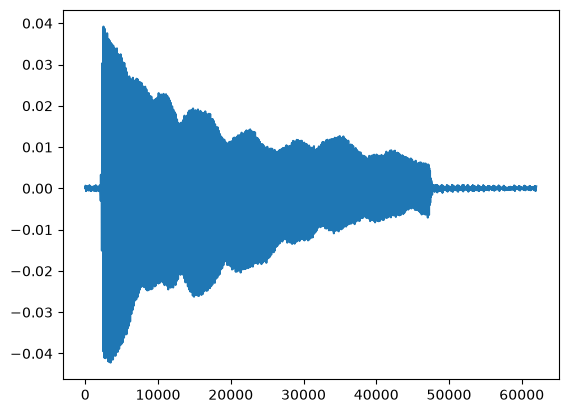

In [33]:
plt.plot(arr[:, 0])

In [34]:
fourier = scipy.fft.rfft(arr[:, 0])

In [35]:
CUTOFF_FREQ = 5e3  # Hz

In [36]:
fs = np.arange(len(fourier)) * sampling_freq / N
fs = fs[fs <= CUTOFF_FREQ]

In [37]:
amplitudes: np.ndarray = np.abs(fourier) / N * 2
amplitudes = amplitudes[: len(fs)] 
amplitudes

array([1.10183493e-06, 3.12401855e-06, 1.28674500e-06, ...,
       4.48535778e-08, 2.58955418e-07, 4.95345973e-07], shape=(7028,))

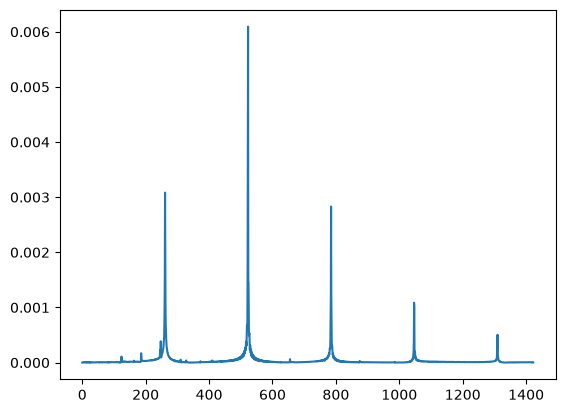

In [38]:
plt.plot(fs[:2000], amplitudes[:2000])

### Extract frequencies

#### My approach

In [39]:
def moving_average(x, w=3):
    return np.convolve(x, np.ones(w), "same") / w


def extract_peak_indices(amplitudes: np.ndarray) -> list[int]:
    # Smoothen out wave
    smooth_amp = moving_average(amplitudes, 5)

    peak_indices: list[int] = []

    # Establish a baseline
    baseline = np.max(amplitudes) / 50

    detecting = False
    current = []
    for i in range(len(smooth_amp)):
        if smooth_amp[i] >= baseline and not detecting:
            detecting = True
            current.append(i)
        elif smooth_amp[i] >= baseline and detecting:
            pass
        elif smooth_amp[i] < baseline and detecting:
            detecting = False
            current.append(i)
            peak_indices.append(
                int(np.argmax(amplitudes[current[0] : current[1]]) + current[0])
            )
            current = []

    return peak_indices

#### Scipy - Maybe this is really it

In [8]:
from scipy.ndimage import median_filter
from scipy.signal import find_peaks

In [ ]:
def sc_extract_peak_indices(
    amplitudes: np.ndarray,
    baseline_window: int = 101,
    min_distance_hz: float = 10 ,
    N: int = N,
    fs: int = sampling_freq,
) -> tuple[np.ndarray, np.ndarray, dict]:
    amplitudes = np.asarray(amplitudes, dtype=float)

    # Median filtering ignores narrow spectral peaks.
    if baseline_window % 2 == 0:
        baseline_window += 1

    baseline = median_filter(
        amplitudes,
        size=baseline_window,
        mode="nearest",
    )

    residual = amplitudes - baseline

    peak_indices, properties = find_peaks(
        residual, distance=min_distance_hz * N / fs, prominence=0.05 * np.max(residual)
    )

    return peak_indices, baseline, properties

In [42]:
sc_peak_indices, baseline, props = sc_extract_peak_indices(amplitudes)

### Find actual note played

In [43]:
peak_indices,_, _ = sc_extract_peak_indices(amplitudes=amplitudes)
peak_frequencies = fs[peak_indices]

In [44]:
base_note = Note(NoteNumber=0, Octave=0)

In [45]:
notes_for_frequency = []


for f in peak_frequencies:
    note = base_note
    chosen = None
    min = np.inf
    while note.Octave < 7:
        semitone_diff = abs(12* np.log2(f/note.frequency))
        if semitone_diff <= 1/10 and semitone_diff < min:
            chosen = note
            min = semitone_diff
        note += 1
    notes_for_frequency.append(chosen)

In [46]:
[n.frequency for n in notes_for_frequency if n is not None]

[261.6255653005986,
 523.2511306011972,
 783.9908719634985,
 1046.5022612023945,
 1567.981743926997]

In [47]:
df = pd.DataFrame(
    {
        "indices": peak_indices,
        "frequencies": peak_frequencies,
        "amplitudes": amplitudes[peak_indices],
        "notes": notes_for_frequency,
    }
)
df["note_names"] = df["notes"].apply(lambda x: x.name if x is not None else None)
df

,indices,frequencies,amplitudes,notes,note_names
0,367,261.102507,0.003083,NoteNumber=0 Octave=4 sharp=True,C4
1,735,522.916465,0.006094,NoteNumber=0 Octave=5 sharp=True,C5
2,1103,784.730423,0.002830,NoteNumber=7 Octave=5 sharp=True,G5
3,1471,1046.544381,0.001086,NoteNumber=0 Octave=6 sharp=True,C6
4,1841,1309.781241,0.000505,None,NaN
5,2211,1573.018101,0.001380,NoteNumber=7 Octave=6 sharp=True,G6
6,2583,1837.677863,0.001461,None,NaN
7,2955,2102.337625,0.000726,None,NaN


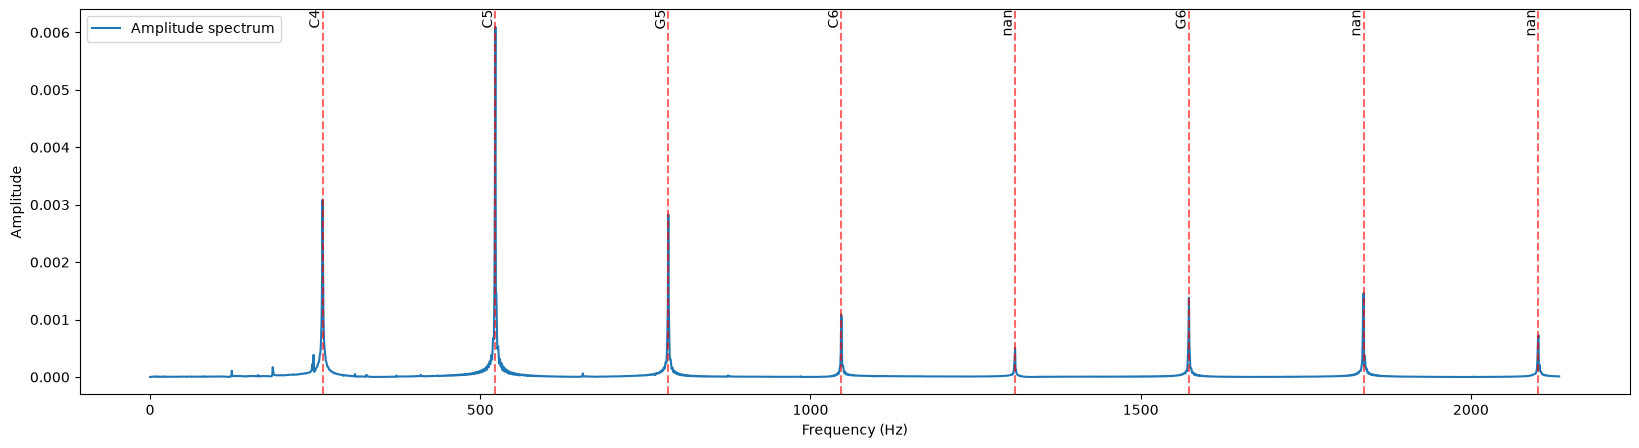

In [48]:
fig, ax = plt.subplots(figsize=[20, 5])

ax.plot(fs[:3000], amplitudes[:3000], label="Amplitude spectrum")

for row in df.iterrows():
    frequency = row[1]["frequencies"]

    if frequency > fs[2999] or row[1]["note_names"] is None:
        continue

    ax.axvline(frequency, linestyle="--", color="red", alpha=0.6)

    ax.text(
        frequency,
        ax.get_ylim()[1],
        row[1]["note_names"],
        rotation=90,
        verticalalignment="top",
        horizontalalignment="right",
    )

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.show()

In [49]:
def choose_notes(df, max_notes = 4) -> Note:
    df2 = df.sort_values("amplitudes",ascending=False).head(max_notes)
    print(df2)
    basenote = df2.sort_values("frequencies").head(1).iloc[0]["notes"]
    # answer= df2[
    #     df2.notes.apply(
    #         lambda x: x.NoteNumber == basenote.NoteNumber if x is not None else False
    #     )
    # ].sort_values("amplitudes", ascending=False).iloc[0]["notes"]
    return basenote

In [50]:
guess = choose_notes(df)
guess.name

   indices  frequencies  amplitudes                             notes  \
1      735   522.916465    0.006094  NoteNumber=0 Octave=5 sharp=True   
0      367   261.102507    0.003083  NoteNumber=0 Octave=4 sharp=True   
2     1103   784.730423    0.002830  NoteNumber=7 Octave=5 sharp=True   
6     2583  1837.677863    0.001461                              None   

  note_names  
1         C5  
0         C4  
2         G5  
6        NaN  


'C4'

In [51]:
guess.frequency

261.6255653005986